# NBA comparison using the nba_api

we will use the NBA API to determine how well the Golden State Warriors performed against the Toronto Raptors. We will use the API to determine the number of points the Golden State Warriors won or lost by for each game. So if the value is three, the Golden State Warriors won by three points. Similarly it the Golden State Warriors lost by two points the result will be negative two. The API will handle a lot of the details, such a Endpoints and Authentication.

### first lets Download the Liberary

In [ ]:
!pip install nba_api

In [13]:
import nba_api
import pandas as pd

### we need the League Games for warriors VS Raptors

we will use the leaguegamefinder endpoint

we need the worrior or Raptors id to get there games, we will use the teams module to get the ID

In [7]:
from nba_api.stats.static import teams  
nba_teams = teams.get_teams()
nba_teams

[{'id': 1610612737,
  'full_name': 'Atlanta Hawks',
  'abbreviation': 'ATL',
  'nickname': 'Hawks',
  'city': 'Atlanta',
  'state': 'Georgia',
  'year_founded': 1949},
 {'id': 1610612738,
  'full_name': 'Boston Celtics',
  'abbreviation': 'BOS',
  'nickname': 'Celtics',
  'city': 'Boston',
  'state': 'Massachusetts',
  'year_founded': 1946},
 {'id': 1610612739,
  'full_name': 'Cleveland Cavaliers',
  'abbreviation': 'CLE',
  'nickname': 'Cavaliers',
  'city': 'Cleveland',
  'state': 'Ohio',
  'year_founded': 1970},
 {'id': 1610612740,
  'full_name': 'New Orleans Pelicans',
  'abbreviation': 'NOP',
  'nickname': 'Pelicans',
  'city': 'New Orleans',
  'state': 'Louisiana',
  'year_founded': 2002},
 {'id': 1610612741,
  'full_name': 'Chicago Bulls',
  'abbreviation': 'CHI',
  'nickname': 'Bulls',
  'city': 'Chicago',
  'state': 'Illinois',
  'year_founded': 1966},
 {'id': 1610612742,
  'full_name': 'Dallas Mavericks',
  'abbreviation': 'DAL',
  'nickname': 'Mavericks',
  'city': 'Dallas',

To easily find our team, i will join the dictionaries and build a dataframe

In [11]:
def join_team_list(dict_list):
    teams_dict = {key: [] for key in dict_list[0].keys()}
    for team in dict_list:
        for key, value in team.items():
                teams_dict[key].append(value)
    return teams_dict

In [14]:
out = join_team_list(nba_teams)
teams_df = pd.DataFrame(out)
teams_df.head()

,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966


find worriers id

In [27]:
warriors_id = teams_df[teams_df['nickname'] == 'Warriors']['id'].values[0]
warriors_id

np.int64(1610612744)

In [28]:
from nba_api.stats.endpoints import leaguegamefinder
gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=warriors_id)

In [51]:
worrier_games_df = gamefinder.get_data_frames()[0]
worrier_games_df.describe()

,TEAM_ID,MIN,PTS,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
count,3.800000e+03,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3799.000000,3777.000000,3800.000000,...,3800.000000,3798.000000,3798.000000,3798.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,2683.000000
mean,1.610613e+09,241.487895,107.573421,40.348421,87.113947,0.463928,7.583684,20.888918,0.343008,19.292895,...,0.757872,12.532649,31.081885,43.614534,24.503684,8.586316,5.122105,15.327105,22.633421,0.604547
std,0.000000e+00,9.337145,14.262233,5.862393,8.162306,0.058047,5.487246,12.883742,0.144170,7.069746,...,0.102706,4.749713,5.885921,6.926943,5.843847,3.176550,2.680265,4.162734,4.832230,15.029446
min,1.610613e+09,50.000000,64.000000,23.000000,59.000000,0.273000,0.000000,0.000000,0.000000,1.000000,...,0.333000,1.000000,11.000000,21.000000,8.000000,1.000000,0.000000,3.000000,5.000000,-53.000000
25%,1.610613e+09,240.000000,98.000000,36.000000,81.000000,0.423000,3.000000,10.000000,0.267000,14.000000,...,0.692000,9.000000,27.000000,39.000000,20.000000,6.000000,3.000000,12.000000,19.000000,-9.000000
50%,1.610613e+09,240.000000,108.000000,40.000000,87.000000,0.463000,7.000000,19.000000,0.350000,19.000000,...,0.765000,12.000000,31.000000,43.000000,24.000000,8.000000,5.000000,15.000000,22.000000,1.000000
75%,1.610613e+09,241.000000,117.000000,44.000000,92.000000,0.506000,11.000000,30.000000,0.429000,24.000000,...,0.833000,15.000000,35.000000,48.000000,28.000000,11.000000,7.000000,18.000000,26.000000,10.000000
max,1.610613e+09,460.000000,162.000000,63.000000,125.000000,0.646000,28.000000,69.000000,1.000000,55.000000,...,1.000000,33.000000,55.000000,72.000000,47.000000,25.000000,18.000000,35.000000,41.000000,58.000000


The column MATCHUP has the team the Warriors were playing, GSW stands for Golden State Warriors and TOR means Toronto Raptors. vs signifies it was a home game and the @ symbol means an away game.

In [57]:
away_games = worrier_games_df[worrier_games_df['MATCHUP'] == 'GSW @ TOR']
away_games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
52,22025,1610612744,GSW,Golden State Warriors,0022500441,2025-12-28,GSW @ TOR,L,265,127,...,0.893,14.0,28.0,42.0,25,9,9,20,20,-14.0
145,22024,1610612744,GSW,Golden State Warriors,0022400550,2025-01-13,GSW @ TOR,L,241,101,...,0.682,14.0,32.0,46.0,23,11,4,14,14,-3.0
214,22023,1610612744,GSW,Golden State Warriors,0022300860,2024-03-01,GSW @ TOR,W,241,120,...,0.778,15.0,41.0,56.0,26,10,5,14,14,15.0
342,22022,1610612744,GSW,Golden State Warriors,0022200448,2022-12-18,GSW @ TOR,W,240,126,...,0.846,12.0,29.0,41.0,31,6,2,17,21,16.0
452,22021,1610612744,GSW,Golden State Warriors,0022100443,2021-12-18,GSW @ TOR,L,240,100,...,0.714,11.0,36.0,47.0,26,5,5,20,21,-19.0


In [56]:
home_games = worrier_games_df[worrier_games_df['MATCHUP'] == 'GSW vs. TOR']
home_games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
39,22025,1610612744,GSW,Golden State Warriors,0022500618,2026-01-20,GSW vs. TOR,L,239,127,...,0.654,14.0,22.0,36.0,28,7,1,17,20,-18.0
114,22024,1610612744,GSW,Golden State Warriors,0022401005,2025-03-20,GSW vs. TOR,W,239,117,...,0.786,11.0,27.0,38.0,30,13,5,14,15,3.0
237,22023,1610612744,GSW,Golden State Warriors,0022300504,2024-01-07,GSW vs. TOR,L,241,118,...,0.933,15.0,28.0,43.0,30,5,4,10,11,-15.0
324,22022,1610612744,GSW,Golden State Warriors,0022200740,2023-01-27,GSW vs. TOR,W,241,129,...,0.733,5.0,38.0,43.0,40,5,1,12,18,12.0
465,22021,1610612744,GSW,Golden State Warriors,0022100252,2021-11-21,GSW vs. TOR,W,241,119,...,0.792,8.0,39.0,47.0,31,5,7,16,18,15.0


<Axes: xlabel='GAME_DATE'>

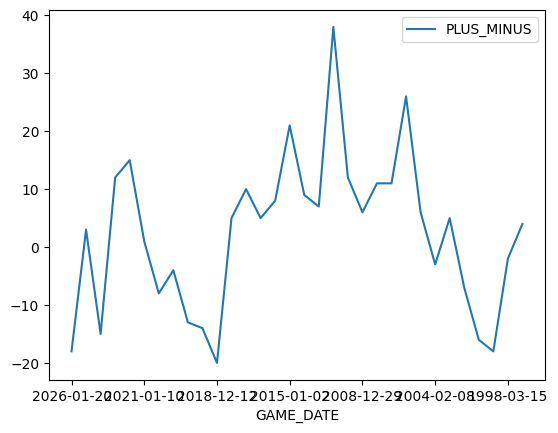

In [ ]:
home_games.plot(x = 'GAME_DATE', y = 'PLUS_MINUS')

<Axes: xlabel='GAME_DATE'>

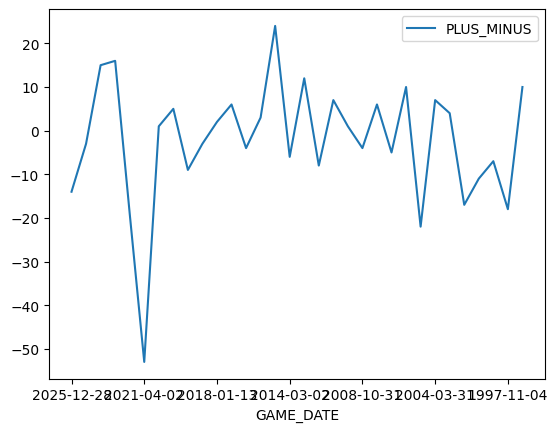

In [61]:
away_games.plot(x = 'GAME_DATE', y = 'PLUS_MINUS')